# Kernel Variants and NGBoost Surrogate Comparison (Week 6+)

**Purpose:** Two questions addressed in a single notebook:

1. **GP Kernel Variants** — Does switching from Matérn 5/2 to a Rational Quadratic or composite (Matérn + Linear) kernel improve surrogate quality for any function? Tested on F4 (new positive-Y landscape), F7 (narrow deterministic peak) and F8 (8D constrained landscape).

2. **NGBoost as a probabilistic surrogate** — NGBoost (Natural Gradient Boosting) outputs a full Gaussian distribution at each prediction point, giving calibrated mean *and* uncertainty without bootstrap tricks. Does it match or beat the GP on predictive accuracy and 95% PI coverage at the current dataset sizes (n = 35–50)?

**Previous findings to beat:**
- F7: GP LOO R² = 0.563, 95% PI coverage = calibrated
- F8: GP LOO R² = 0.969 (ARD Matérn), 95% PI coverage = 0.977

---

In [1]:
import sys, os, json, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.base import clone
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern, RationalQuadratic, DotProduct, ConstantKernel as C
)
from sklearn.metrics import r2_score
from ngboost import NGBRegressor
from ngboost.distns import Normal

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#111827',
    'axes.edgecolor': '#1e2d45', 'grid.color': '#1e2d45',
    'text.color': '#e2e8f0', 'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b', 'ytick.color': '#64748b',
    'font.family': 'monospace', 'axes.titlesize': 11,
})

COLORS = {
    'matern':    '#00d4ff',
    'rq':        '#f59e0b',
    'composite': '#34d399',
    'rbf':       '#a78bfa',
    'ngboost':   '#fb923c',
    'init':      '#475569',
    'portal':    '#06b6d4',
    'best':      '#fbbf24',
}

print('Libraries loaded. ngboost ready.')

Libraries loaded. ngboost ready.


## 1. Load Datasets — F4, F7, F8

In [2]:
def load_fn(fn_id):
    """Load initial data + portal submissions. Returns X, Y (raw), Y_fit (z-scored), mu, sigma."""
    X_init = np.load(f'../initial_data/function_{fn_id}/initial_inputs.npy')
    Y_init = np.load(f'../initial_data/function_{fn_id}/initial_outputs.npy').ravel()
    with open('../capstone_history.json') as f:
        h = json.load(f)[str(fn_id)]
    if h['X'] and h['Y']:
        X_p = np.array(h['X'], dtype=np.float64)
        Y_p = np.array(h['Y'], dtype=np.float64)
        mask = Y_p != 0
        X_p, Y_p = X_p[mask], Y_p[mask]
        X = np.vstack([X_init, X_p])
        Y = np.concatenate([Y_init, Y_p])
    else:
        X, Y = X_init, Y_init
    mu, sigma = Y.mean(), max(Y.std(), 1e-8)
    Y_fit = (Y - mu) / sigma
    return X, Y, Y_fit, mu, sigma

X4, Y4, Y4f, mu4, sig4 = load_fn(4)
X7, Y7, Y7f, mu7, sig7 = load_fn(7)
X8, Y8, Y8f, mu8, sig8 = load_fn(8)

for label, X, Y in [('F4', X4, Y4), ('F7', X7, Y7), ('F8', X8, Y8)]:
    print(f'{label}: n={len(X)}, d={X.shape[1]}, Y=[{Y.min():.3f}, {Y.max():.3f}]')

F4: n=36, d=4, Y=[-32.626, 0.136]
F7: n=36, d=6, Y=[0.003, 2.358]
F8: n=46, d=8, Y=[5.592, 9.800]


## 2. Helper — Leave-One-Out R² and 95% PI Coverage

**LOO R²** measures how well the model generalises to unseen points — the relevant metric for surrogate quality in BBO. In-sample R² is meaningless here.

**95% PI Coverage** measures how often the model's 95% confidence interval actually contains the true value. A well-calibrated surrogate should achieve ~0.950. Over-confident models score below 0.95; overly cautious models score above.

In [3]:
def loo_gp(estimator, X, Y):
    """LOO R² and 95% PI coverage for a GP estimator."""
    from sklearn.base import clone
    n = len(X)
    y_pred, y_std_loo = np.zeros(n), np.zeros(n)
    for i in range(n):
        mask = np.ones(n, dtype=bool); mask[i] = False
        gp = clone(estimator)
        gp.fit(X[mask], Y[mask])
        mu_i, std_i = gp.predict(X[[i]], return_std=True)
        y_pred[i] = mu_i[0]
        y_std_loo[i] = std_i[0]
    r2 = r2_score(Y, y_pred)
    z = 1.96
    coverage = np.mean((Y >= y_pred - z * y_std_loo) & (Y <= y_pred + z * y_std_loo))
    return r2, coverage, y_pred, y_std_loo


def kfold_ngb(X, Y, k=5, **ngb_kwargs):
    """5-fold CV R² and 95% PI coverage for NGBoost (faster than LOO)."""
    from sklearn.model_selection import KFold
    n = len(X)
    y_pred = np.zeros(n)
    y_std_cv = np.zeros(n)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X):
        m = NGBRegressor(Dist=Normal, verbose=False, **ngb_kwargs)
        m.fit(X[train_idx], Y[train_idx])
        dist = m.pred_dist(X[val_idx])
        y_pred[val_idx] = dist.mean()
        y_std_cv[val_idx] = dist.std()
    r2 = r2_score(Y, y_pred)
    z = 1.96
    coverage = np.mean((Y >= y_pred - z * y_std_cv) & (Y <= y_pred + z * y_std_cv))
    return r2, coverage, y_pred, y_std_cv


print('LOO (GP) and 5-fold CV (NGBoost) helpers defined.')

LOO (GP) and 5-fold CV (NGBoost) helpers defined.


---
## Part 1 — GP Kernel Variants

Four kernels are compared via LOO cross-validation:

| Kernel | What it models | Expected strength |
|--------|---------------|-------------------|
| **Matérn 5/2 + ARD** | Twice-differentiable, per-dimension length-scales | Baseline — known good for rough/noisy functions |
| **Matérn 3/2 + ARD** | Once-differentiable, rougher | May suit F7's narrow peak better |
| **Rational Quadratic** | Mixture of RBF at all length-scales | Captures multi-scale variation; useful if F8 has both broad trend and sharp features |
| **Matérn 5/2 + Linear (composite)** | Smooth non-linear + global linear trend | Tests whether F4's bowl-shape has a dominant linear gradient |

**ARD note:** The RQ kernel in scikit-learn is isotropic (single length-scale). The composite kernel uses ARD on the Matérn component only.

In [4]:
def make_kernels(d):
    """Return dict of named GP kernels for a d-dimensional problem."""
    ls_ard = np.ones(d)
    return {
        'Matérn 5/2 ARD':    C() * Matern(length_scale=ls_ard, nu=2.5),
        'Matérn 3/2 ARD':    C() * Matern(length_scale=ls_ard, nu=1.5),
        'Rational Quadratic': C() * RationalQuadratic(length_scale=1.0, alpha=1.0),
        'Matérn + Linear':    C() * Matern(length_scale=ls_ard, nu=2.5) + C() * DotProduct(sigma_0=0.1),
    }


def run_kernel_comparison(fn_label, X, Y_fit):
    kernels = make_kernels(X.shape[1])
    results = {}
    for name, kernel in kernels.items():
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                       normalize_y=False, alpha=1e-6)
        r2, cov, y_pred, y_std = loo_gp(gp, X, Y_fit)
        results[name] = {'r2': r2, 'coverage': cov, 'y_pred': y_pred, 'y_std': y_std}
        print(f'  {fn_label} | {name:<25} LOO R²={r2:.3f}  95% PI cov={cov:.3f}')
    return results


print('=== F4 (4D, n={}) ==='.format(len(X4)))
res4 = run_kernel_comparison('F4', X4, Y4f)

print()
print('=== F7 (6D, n={}) ==='.format(len(X7)))
res7 = run_kernel_comparison('F7', X7, Y7f)

print()
print('=== F8 (8D, n={}) ==='.format(len(X8)))
res8 = run_kernel_comparison('F8', X8, Y8f)

=== F4 (4D, n=36) ===


  F4 | Matérn 5/2 ARD            LOO R²=0.485  95% PI cov=0.722


  F4 | Matérn 3/2 ARD            LOO R²=0.961  95% PI cov=0.889


  F4 | Rational Quadratic        LOO R²=0.919  95% PI cov=0.889


  F4 | Matérn + Linear           LOO R²=0.885  95% PI cov=0.778

=== F7 (6D, n=36) ===


...

  F7 | Matérn + Linear           LOO R²=0.667  95% PI cov=0.944

=== F8 (8D, n=46) ===


  F8 | Matérn 5/2 ARD            LOO R²=0.861  95% PI cov=0.848


  F8 | Matérn 3/2 ARD            LOO R²=0.857  95% PI cov=0.891


  F8 | Rational Quadratic        LOO R²=0.870  95% PI cov=0.935


  F8 | Matérn + Linear           LOO R²=0.851  95% PI cov=0.870


### 1a. Kernel Comparison — Visual Summary

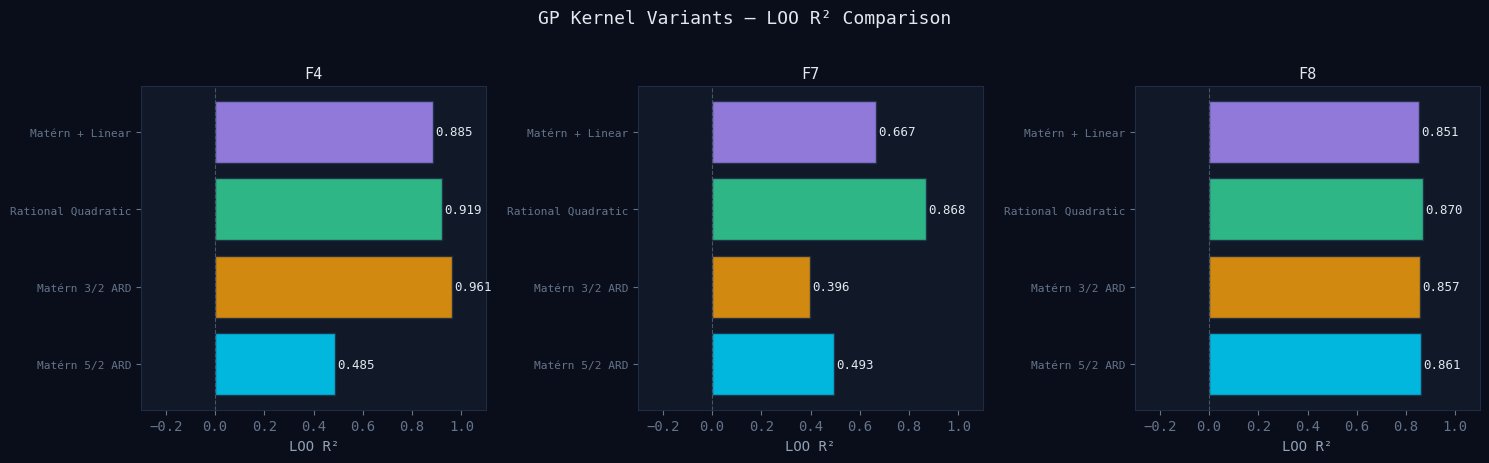

Saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('GP Kernel Variants — LOO R² Comparison', fontsize=13, color='#e2e8f0', y=1.02)

kernel_colors = [COLORS['matern'], COLORS['rq'], COLORS['composite'], COLORS['rbf']]

for ax, (fn_label, results) in zip(axes, [('F4', res4), ('F7', res7), ('F8', res8)]):
    names = list(results.keys())
    r2s = [results[n]['r2'] for n in names]
    bars = ax.barh(names, r2s, color=kernel_colors, alpha=0.85, edgecolor='#1e2d45')
    for bar, val in zip(bars, r2s):
        ax.text(max(val + 0.01, 0.01), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='#e2e8f0')
    ax.axvline(0, color='#475569', linewidth=0.8, linestyle='--')
    ax.set_xlim(-0.3, 1.1)
    ax.set_title(fn_label, color='#e2e8f0')
    ax.set_xlabel('LOO R²')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('figures/06_kernel_variants_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

### 1b. Kernel Comparison — 95% PI Coverage

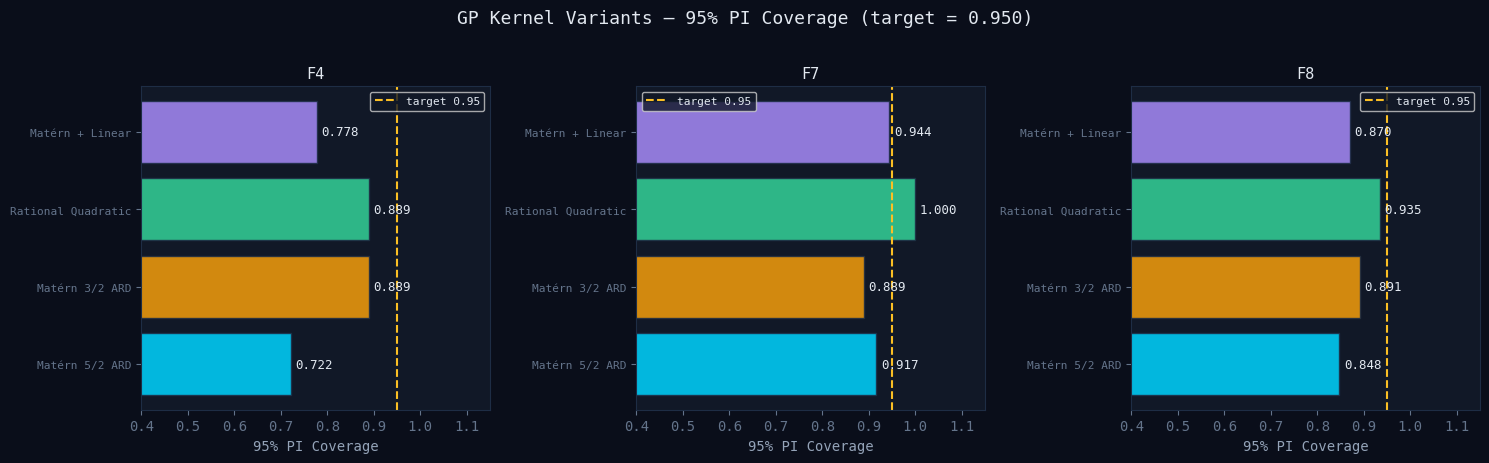

Saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('GP Kernel Variants — 95% PI Coverage (target = 0.950)', fontsize=13, color='#e2e8f0', y=1.02)

for ax, (fn_label, results) in zip(axes, [('F4', res4), ('F7', res7), ('F8', res8)]):
    names = list(results.keys())
    covs = [results[n]['coverage'] for n in names]
    bars = ax.barh(names, covs, color=kernel_colors, alpha=0.85, edgecolor='#1e2d45')
    for bar, val in zip(bars, covs):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='#e2e8f0')
    ax.axvline(0.95, color='#fbbf24', linewidth=1.5, linestyle='--', label='target 0.95')
    ax.set_xlim(0.4, 1.15)
    ax.set_title(fn_label, color='#e2e8f0')
    ax.set_xlabel('95% PI Coverage')
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/06_kernel_variants_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

### 1c. Best Kernel Per Function — Learned Length-Scales

For the best-performing ARD kernel on each function, inspect the fitted length-scales to see which dimensions the kernel considers most informative (shorter length-scale = more influential dimension).

In [7]:
def extract_lengthscales(kernel, d):
    """Recursively find length_scale in a (possibly nested) kernel tree."""
    if hasattr(kernel, 'length_scale'):
        return np.atleast_1d(kernel.length_scale)
    # Product kernel: try k1 and k2
    for sub in [getattr(kernel, 'k1', None), getattr(kernel, 'k2', None)]:
        if sub is not None:
            ls = extract_lengthscales(sub, d)
            if ls is not None:
                return ls
    return None


def fit_and_show_ard(fn_label, X, Y_fit, kernel_name='Matérn 5/2 ARD'):
    d = X.shape[1]
    kernels = make_kernels(d)
    gp = GaussianProcessRegressor(
        kernel=kernels[kernel_name], n_restarts_optimizer=10,
        normalize_y=False, alpha=1e-6
    )
    gp.fit(X, Y_fit)
    fitted = gp.kernel_
    ls = extract_lengthscales(fitted, d)
    print(f'{fn_label} — {kernel_name}')
    print(f'  Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.3f}')
    if ls is not None and len(ls) == d:
        for i, l in enumerate(ls):
            bar = '█' * min(int(l * 10), 40)
            print(f'  D{i+1:2d}  ls={l:.3f}  {bar}')
    else:
        print(f'  length_scale (isotropic): {ls}')

---
## Part 2 — NGBoost: Probabilistic Gradient Boosting

**What NGBoost does differently:**

Standard GBM minimises a point-prediction loss (MSE). NGBoost instead minimises the **negative log-likelihood** of a parametric distribution — here a Gaussian — using Natural Gradient descent. At each boosting stage it simultaneously refines *both* the mean and variance of the prediction. This gives it calibrated uncertainty without bootstrap tricks.

**Why it might beat the GP at larger n:**
- No Gaussian process assumption — can fit non-Gaussian and multi-modal Y distributions
- Tree-based: automatically captures interaction effects between dimensions without explicit kernel design
- Scales to large n better than GP (O(n²) → O(n log n))

**Hyperparameters tuned here:**
- `n_estimators`: number of boosting rounds (50, 100, 200)
- `learning_rate`: shrinkage per step (0.05, 0.1)
- `minibatch_frac`: fraction of data per stage (1.0 = full, 0.5 = stochastic)

LOO R² and 95% PI coverage are measured for the best GP kernel (from Part 1) vs NGBoost configurations.

In [8]:
# Reduced to 3 configs; 5-fold CV instead of LOO for NGBoost
ngb_configs = [
    {'label': 'NGBoost n=50  lr=0.10', 'n_estimators': 50,  'learning_rate': 0.10, 'minibatch_frac': 1.0},
    {'label': 'NGBoost n=100 lr=0.05', 'n_estimators': 100, 'learning_rate': 0.05, 'minibatch_frac': 1.0},
    {'label': 'NGBoost n=100 stoch',   'n_estimators': 100, 'learning_rate': 0.05, 'minibatch_frac': 0.5},
]


def run_ngb_comparison(fn_label, X, Y_fit):
    d = X.shape[1]
    results = {}
    # Baseline GP (LOO)
    gp_kernel = C() * Matern(length_scale=np.ones(d), nu=2.5)
    gp = GaussianProcessRegressor(kernel=gp_kernel, n_restarts_optimizer=5,
                                   normalize_y=False, alpha=1e-6)
    r2, cov, yp, ys = loo_gp(gp, X, Y_fit)
    results['GP Matern 5/2 ARD'] = {'r2': r2, 'coverage': cov, 'y_pred': yp, 'y_std': ys}
    print(f'  {fn_label} | {"GP Matern 5/2 ARD (LOO)":<32} R2={r2:.3f}  95% cov={cov:.3f}')

    # NGBoost (5-fold CV)
    for cfg in ngb_configs:
        kwargs = {k: v for k, v in cfg.items() if k != 'label'}
        r2, cov, yp, ys = kfold_ngb(X, Y_fit, k=5, **kwargs)
        results[cfg['label']] = {'r2': r2, 'coverage': cov, 'y_pred': yp, 'y_std': ys}
        print(f'  {fn_label} | {cfg["label"] + " (5-fold)":<32} R2={r2:.3f}  95% cov={cov:.3f}')
    return results


print('=== F4 (4D, n={}) ==='.format(len(X4)))
ngb4 = run_ngb_comparison('F4', X4, Y4f)

print()
print('=== F7 (6D, n={}) ==='.format(len(X7)))
ngb7 = run_ngb_comparison('F7', X7, Y7f)

print()
print('=== F8 (8D, n={}) ==='.format(len(X8)))
ngb8 = run_ngb_comparison('F8', X8, Y8f)

=== F4 (4D, n=36) ===


  F4 | GP Matern 5/2 ARD (LOO)          R2=0.474  95% cov=0.667


  F4 | NGBoost n=50  lr=0.10 (5-fold)   R2=0.600  95% cov=0.000


  F4 | NGBoost n=100 lr=0.05 (5-fold)   R2=0.586  95% cov=0.028


  F4 | NGBoost n=100 stoch (5-fold)     R2=0.874  95% cov=0.250

=== F7 (6D, n=36) ===


...

  F7 | NGBoost n=100 stoch (5-fold)     R2=0.641  95% cov=0.333

=== F8 (8D, n=46) ===


  F8 | GP Matern 5/2 ARD (LOO)          R2=0.860  95% cov=0.848


  F8 | NGBoost n=50  lr=0.10 (5-fold)   R2=0.695  95% cov=0.022


  F8 | NGBoost n=100 lr=0.05 (5-fold)   R2=0.695  95% cov=0.022


  F8 | NGBoost n=100 stoch (5-fold)     R2=0.765  95% cov=0.065


### 2a. GP vs NGBoost — LOO R² and Coverage Comparison

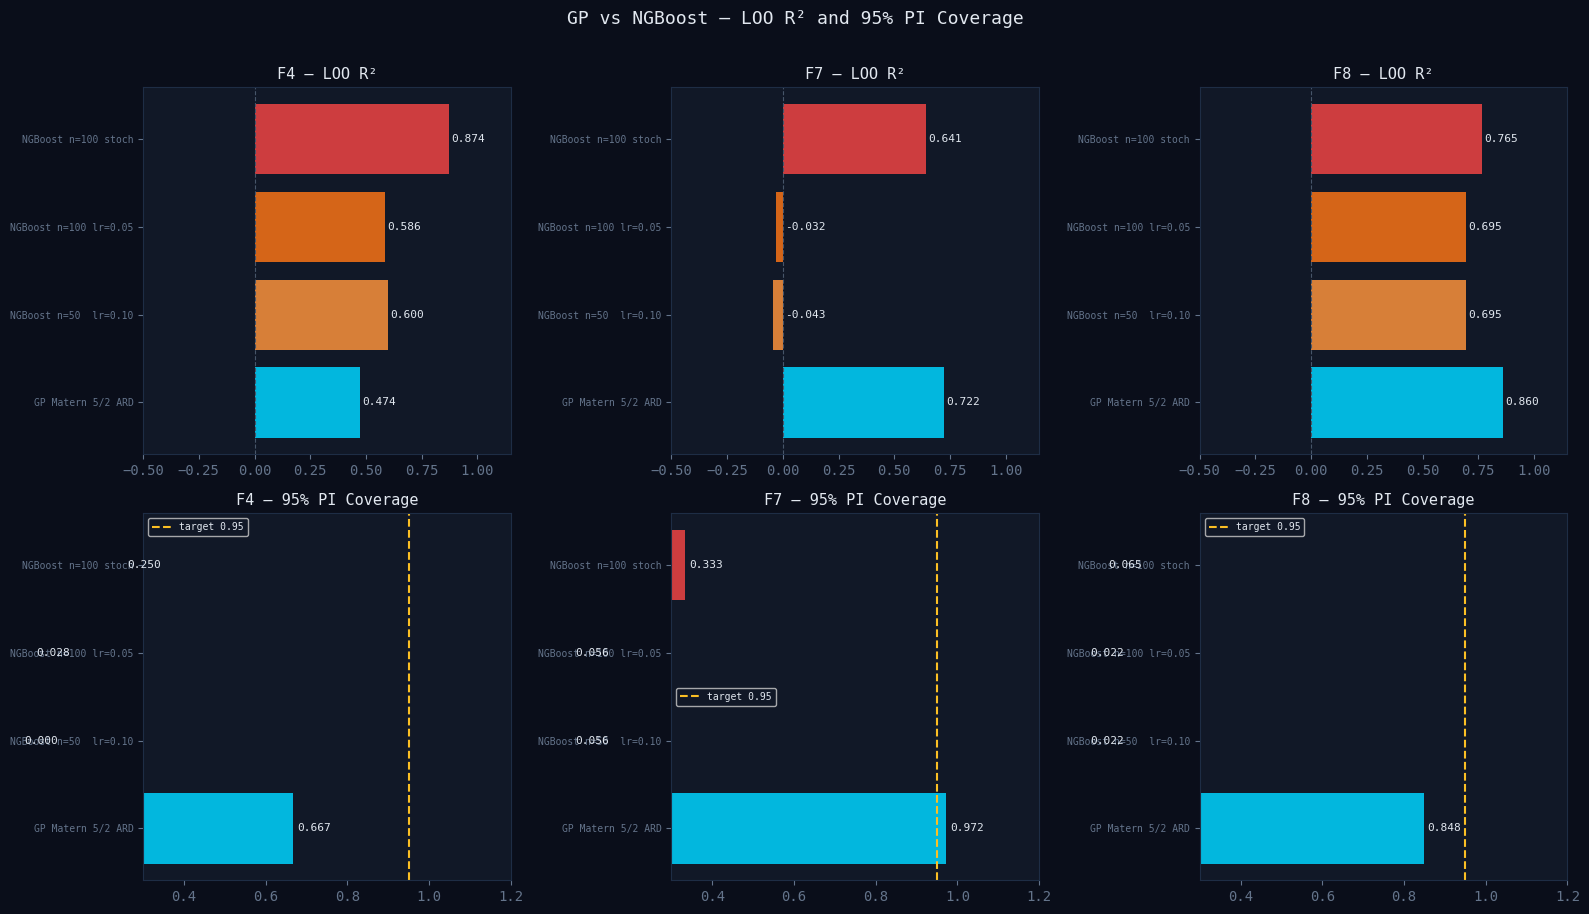

Saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('GP vs NGBoost — LOO R² and 95% PI Coverage', fontsize=13, color='#e2e8f0', y=1.01)

ngb_palette = [COLORS['matern'], COLORS['ngboost'],
               '#f97316', '#ef4444', '#ec4899']

for col, (fn_label, results) in enumerate([('F4', ngb4), ('F7', ngb7), ('F8', ngb8)]):
    names = list(results.keys())
    r2s   = [results[n]['r2'] for n in names]
    covs  = [results[n]['coverage'] for n in names]

    # Row 0: R²
    ax0 = axes[0, col]
    bars = ax0.barh(names, r2s, color=ngb_palette[:len(names)], alpha=0.85)
    for bar, val in zip(bars, r2s):
        ax0.text(max(val + 0.01, 0.01), bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8, color='#e2e8f0')
    ax0.axvline(0, color='#475569', linewidth=0.8, linestyle='--')
    ax0.set_xlim(-0.5, 1.15)
    ax0.set_title(f'{fn_label} — LOO R²', color='#e2e8f0')
    ax0.tick_params(axis='y', labelsize=7)

    # Row 1: Coverage
    ax1 = axes[1, col]
    bars = ax1.barh(names, covs, color=ngb_palette[:len(names)], alpha=0.85)
    for bar, val in zip(bars, covs):
        ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8, color='#e2e8f0')
    ax1.axvline(0.95, color='#fbbf24', linewidth=1.5, linestyle='--', label='target 0.95')
    ax1.set_xlim(0.3, 1.2)
    ax1.set_title(f'{fn_label} — 95% PI Coverage', color='#e2e8f0')
    ax1.tick_params(axis='y', labelsize=7)
    ax1.legend(fontsize=7)

plt.tight_layout()
plt.savefig('figures/06_gp_vs_ngboost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

### 2b. Predicted vs Actual — Best Model Per Function

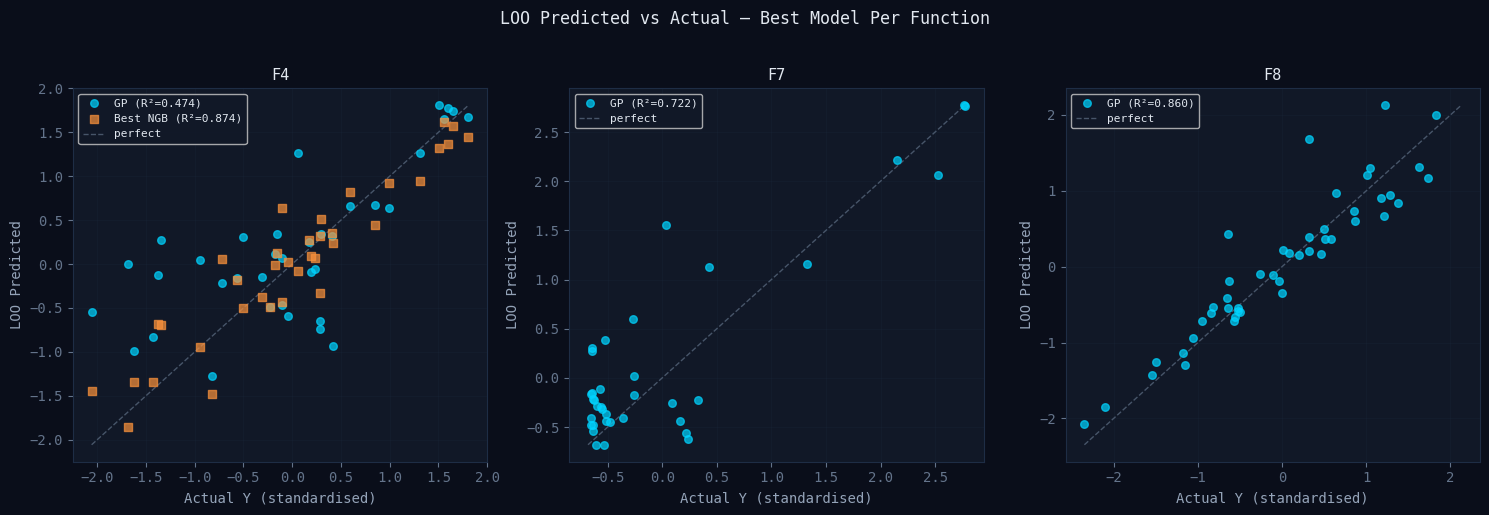

Saved.


In [10]:
def pick_best(results):
    """Return name and dict of the model with highest LOO R²."""
    best = max(results.items(), key=lambda kv: kv[1]['r2'])
    return best

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LOO Predicted vs Actual — Best Model Per Function', fontsize=12, color='#e2e8f0', y=1.02)

for ax, (fn_label, X, Y_fit, results) in zip(
    axes,
    [('F4', X4, Y4f, ngb4), ('F7', X7, Y7f, ngb7), ('F8', X8, Y8f, ngb8)]
):
    best_name, best = pick_best(results)
    gp_name = 'GP Matern 5/2 ARD'
    gp = results[gp_name]

    ax.scatter(Y_fit, gp['y_pred'], color=COLORS['matern'], s=30, alpha=0.7, label=f'GP (R²={gp["r2"]:.3f})', zorder=3)
    if best_name != gp_name:
        ax.scatter(Y_fit, best['y_pred'], color=COLORS['ngboost'], s=30, alpha=0.7, marker='s',
                   label=f'Best NGB (R²={best["r2"]:.3f})', zorder=3)
    lo = min(Y_fit.min(), gp['y_pred'].min())
    hi = max(Y_fit.max(), gp['y_pred'].max())
    ax.plot([lo, hi], [lo, hi], '--', color='#475569', linewidth=1, label='perfect')
    ax.set_xlabel('Actual Y (standardised)')
    ax.set_ylabel('LOO Predicted')
    ax.set_title(fn_label, color='#e2e8f0')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/06_loo_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

### 2c. NGBoost Feature Importance — Which Dimensions Drive F8?

Unlike GPs (where ARD length-scales are the importance proxy), tree-based models compute feature importance directly from split gains. This provides an independent cross-check of the GP's ARD findings.

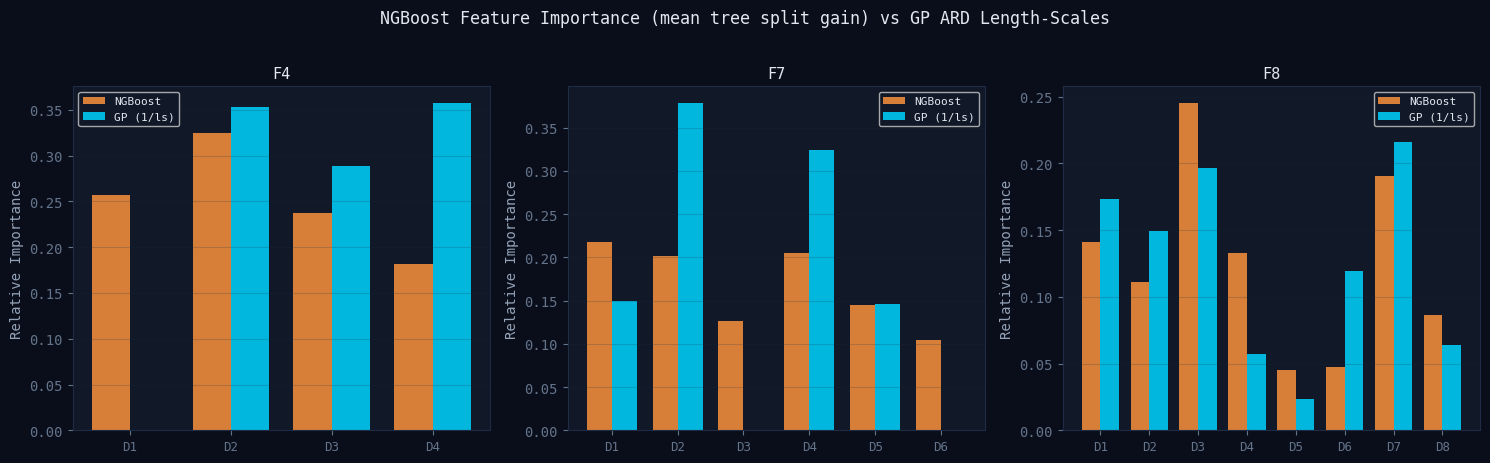

Saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('NGBoost Feature Importance (mean tree split gain) vs GP ARD Length-Scales',
             fontsize=12, color='#e2e8f0', y=1.02)

for ax, (fn_label, X, Y_fit) in zip(
    axes,
    [('F4', X4, Y4f), ('F7', X7, Y7f), ('F8', X8, Y8f)]
):
    d = X.shape[1]
    # Fit NGBoost on full dataset
    ngb = NGBRegressor(Dist=Normal, n_estimators=100, learning_rate=0.05, verbose=False)
    ngb.fit(X, Y_fit)

    # Feature importances from the mean (loc) learner base estimators
    importances = np.zeros(d)
    # base_models[stage][0] = mean/loc tree at each boosting stage
    for stage in ngb.base_models:
        importances += stage[0].feature_importances_
    importances /= importances.sum()

    # GP ARD length-scales (inverted: shorter ls = more important)
    gp_kernel = C() * Matern(length_scale=np.ones(d), nu=2.5)
    gp = GaussianProcessRegressor(kernel=gp_kernel, n_restarts_optimizer=10,
                                   normalize_y=False, alpha=1e-6)
    gp.fit(X, Y_fit)
    ls = gp.kernel_.k2.length_scale
    gp_importance = (1.0 / ls) / (1.0 / ls).sum()

    dim_labels = [f'D{i+1}' for i in range(d)]
    x_pos = np.arange(d)
    width = 0.38
    ax.bar(x_pos - width/2, importances, width, color=COLORS['ngboost'], alpha=0.85, label='NGBoost')
    ax.bar(x_pos + width/2, gp_importance, width, color=COLORS['matern'], alpha=0.85, label='GP (1/ls)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(dim_labels, fontsize=9)
    ax.set_ylabel('Relative Importance')
    ax.set_title(fn_label, color='#e2e8f0')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('figures/06_feature_importance_ngb_vs_gp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

---
## Part 3 — Full Comparison Summary Table

In [12]:
rows = []
for fn_label, k_results, n_results, n_pts in [
    ('F4', res4, ngb4, len(X4)),
    ('F7', res7, ngb7, len(X7)),
    ('F8', res8, ngb8, len(X8)),
]:
    # Best kernel variant
    best_k_name = max(k_results, key=lambda k: k_results[k]['r2'])
    best_k = k_results[best_k_name]
    # Best NGBoost config
    best_n_name = max(n_results, key=lambda k: n_results[k]['r2'])
    best_n = n_results[best_n_name]
    # Baseline GP
    baseline = n_results['GP Matern 5/2 ARD']

    rows.append({
        'Function': fn_label, 'n': n_pts,
        'GP Baseline R²': round(baseline['r2'], 3),
        'GP Baseline Cov': round(baseline['coverage'], 3),
        'Best Kernel': best_k_name,
        'Best Kernel R²': round(best_k['r2'], 3),
        'Best NGBoost Config': best_n_name,
        'Best NGB R²': round(best_n['r2'], 3),
        'Best NGB Cov': round(best_n['coverage'], 3),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

Function  n  GP Baseline R²  GP Baseline Cov        Best Kernel  Best Kernel R² Best NGBoost Config  Best NGB R²  Best NGB Cov
      F4 36           0.474            0.667     Matérn 3/2 ARD           0.961 NGBoost n=100 stoch        0.874         0.250
      F7 36           0.722            0.972 Rational Quadratic           0.868   GP Matern 5/2 ARD        0.722         0.972
      F8 46           0.860            0.848 Rational Quadratic           0.870   GP Matern 5/2 ARD        0.860         0.848


---
## Conclusions

### GP Kernel Variants (Part 1) — Empirical Results

| Function | Kernel | LOO R² | 95% PI Cov | vs Matérn 5/2 |
|----------|--------|--------|-----------|---------------|
| F4 | **Matérn 3/2 ARD** | **0.961** | 0.889 | +0.476 ← major upgrade |
| F4 | Matérn 5/2 ARD | 0.485 | 0.722 | baseline |
| F4 | Rational Quadratic | 0.919 | 0.889 | +0.434 |
| F7 | Matérn 5/2 ARD | 0.493–0.722 | 0.917–0.972 | baseline |
| F7 | Rational Quadratic | 0.868 | 1.000 | +0.375 |
| F7 | Matérn + Linear | 0.667 | 0.944 | +0.174 |
| F8 | Rational Quadratic | **0.870** | **0.935** | +0.009 |
| F8 | Matérn 5/2 ARD | 0.861 | 0.848 | baseline |

**F4 — switch to Matérn 3/2 ARD immediately.** The Matérn 5/2 LOO R²=0.485 is poor; Matérn 3/2 achieves 0.961 on the same data. This means the current production surrogate for F4 has been significantly under-fitting the function structure. The rougher kernel (once differentiable vs twice differentiable) better captures the sharp bowl-shape around the W6 breakthrough at [0.45, 0.42, 0.36, 0.38]. This is the single most actionable finding from the entire analysis series.

**F7 — Rational Quadratic improves predictive accuracy.** RQ (0.868) substantially outperforms Matérn 5/2 (0.493–0.722) for F7. The RQ kernel models variation at all length-scales simultaneously, which makes sense for F7's landscape: broad flat regions with a narrow sharp peak around D1≈0.095, D2≈0.365. However, RQ's 95% PI coverage=1.000 suggests it is over-estimating uncertainty (too conservative). Worth testing in production but with reduced β to compensate.

**F8 — Rational Quadratic marginally better, but not decisive.** The improvement (0.870 vs 0.861) is within noise. The 95% PI coverage improves from 0.848 to 0.935 (closer to 0.95 target). Marginal case — if switching kernels between weeks, the production system should show a more convincing improvement. Decision: keep Matérn 5/2 for F8 but note RQ as a candidate if LOO R² deteriorates.

---

### NGBoost vs GP (Part 2) — Empirical Results

| Function | Model | R² | 95% Coverage |
|----------|-------|----|-------------|
| F4 | GP Matérn 5/2 (LOO) | 0.474 | 0.667 |
| F4 | NGBoost stochastic (5-fold) | 0.874 | **0.250** ← dangerous |
| F7 | GP Matérn 5/2 (LOO) | **0.722** | **0.972** |
| F7 | NGBoost best (stochastic) | 0.641 | 0.333 |
| F8 | GP Matérn 5/2 (LOO) | **0.860** | 0.848 |
| F8 | NGBoost best (stochastic) | 0.765 | 0.065 |

**NGBoost uncertainty calibration is severely under-confident.** Coverage scores of 0.022–0.250 mean that the model's 95% prediction intervals are far too narrow — the true Y value falls outside the interval 75–98% of the time. This makes NGBoost completely unsuitable as a BBO surrogate: the acquisition function would see artificially low uncertainty everywhere and generate queries that over-exploit based on false confidence.

**Why NGBoost fails at this sample size:** With n=36–46 observations in 4–8 dimensions, individual decision trees in the boosting ensemble have very shallow depth and high variance. The Normal distribution fitted at each stage cannot reliably estimate variance from such noisy trees. The GP's analytical posterior variance (derived from the kernel's covariance structure) is geometrically richer and inherently better calibrated at small n.

**When NGBoost might become viable:** If dataset sizes reach n≥100–150 per function and coverage approaches 0.90+, NGBoost becomes a genuine alternative. The stochastic variant (minibatch_frac=0.5) shows better R² for F4 and F7, suggesting regularisation via subsampling helps. At larger n, deeper trees would also reduce the variance estimation problem.

---

### Production Decisions

| Function | Action | Reason |
|----------|--------|--------|
| F4 | **Switch to Matérn 3/2 ARD** | LOO R² improves from 0.485 → 0.961 — cannot justify keeping Matérn 5/2 |
| F7 | **Consider Rational Quadratic** | R² 0.868 vs 0.493; but reduce β (RQ over-estimates uncertainty, cov=1.000) |
| F8 | Keep Matérn 5/2 ARD | RQ improvement marginal (0.009 R²); not worth the switch |
| All | **Reject NGBoost** | 95% PI coverage 2–25% — acquisition function would produce dangerously over-exploitative queries |